In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import sys
import random
import re
import importlib

BASE_DIR = Path('/content/drive/MyDrive/먼작귀')

COMMON_DIR = BASE_DIR / 'synthetic_scenarios'
FRONT_DIR = COMMON_DIR / 'front'

candidate_project_dirs = [
    Path.cwd(),
    COMMON_DIR,
    FRONT_DIR,
]

candidate_project_dirs += [
    p.parent for p in Path('/content/drive').glob(
        '.shortcut-targets-by-id/*/*/synthetic_scenarios/front/shelf_synthetic_common.py'
    )
]

PROJECT_DIR = None
for d in candidate_project_dirs:
    if (d / 'shelf_synthetic_common.py').exists():
        PROJECT_DIR = d
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        'shelf_synthetic_common.py 파일을 찾지 못했습니다. '
        '노트북(.ipynb)과 shelf_synthetic_common.py를 같은 폴더에 두거나, '
        'PROJECT_DIR를 실제 파일 위치로 수정해주세요.'
    )

LABELER_DIR = COMMON_DIR

if not (LABELER_DIR / 'synthetic_label_exporter.py').exists():
    raise FileNotFoundError(
        f'synthetic_label_exporter.py 파일을 찾지 못했습니다: {LABELER_DIR}'
    )

# shelf_synthetic_common.py는 front 폴더에서,
# synthetic_label_exporter.py는 synthetic_scenarios 공통 폴더에서 import
for p in [PROJECT_DIR, LABELER_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print('공통 py 파일 위치:', PROJECT_DIR / 'shelf_synthetic_common.py')
print('라벨 exporter 위치:', LABELER_DIR / 'synthetic_label_exporter.py')
print('BASE_DIR:', BASE_DIR)

import shelf_synthetic_common as synth
import synthetic_label_exporter as labeler

importlib.reload(synth)
importlib.reload(labeler)

ctx = synth.create_synthetic_context(
    base_dir=BASE_DIR,
    background_name='선반이미지_정면.png',
    seed=42,
)

print("shelf_lip_polygons 개수:", len(ctx.get("shelf_lip_polygons", [])))
print("context 생성 완료")

공통 py 파일 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/front/shelf_synthetic_common.py
라벨 exporter 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/synthetic_label_exporter.py
BASE_DIR: /content/drive/MyDrive/먼작귀
shelf_lip_polygons 개수: 5
context 생성 완료


S3 정면 생성 중:   0%|          | 0/200 [00:00<?, ?img/s]

[20/200] 완료 | 최근 파일: synthetic_s3_020.png | 열 공백 대상: 5개 | ctx: 0.3초 | render: 17.24초 | label: 2.87초 | 평균: 23.42초/장 | 예상 남은 시간: 70.3분
[40/200] 완료 | 최근 파일: synthetic_s3_040.png | 열 공백 대상: 1개 | ctx: 0.33초 | render: 18.19초 | label: 2.89초 | 평균: 22.81초/장 | 예상 남은 시간: 60.8분
[60/200] 완료 | 최근 파일: synthetic_s3_060.png | 열 공백 대상: 5개 | ctx: 0.28초 | render: 20.08초 | label: 2.86초 | 평균: 22.68초/장 | 예상 남은 시간: 52.9분
[80/200] 완료 | 최근 파일: synthetic_s3_080.png | 열 공백 대상: 1개 | ctx: 0.3초 | render: 18.23초 | label: 2.95초 | 평균: 22.56초/장 | 예상 남은 시간: 45.1분
[100/200] 완료 | 최근 파일: synthetic_s3_100.png | 열 공백 대상: 6개 | ctx: 0.3초 | render: 17.93초 | label: 3.45초 | 평균: 22.51초/장 | 예상 남은 시간: 37.5분
[120/200] 완료 | 최근 파일: synthetic_s3_120.png | 열 공백 대상: 3개 | ctx: 0.45초 | render: 18.93초 | label: 2.94초 | 평균: 22.46초/장 | 예상 남은 시간: 29.9분
[140/200] 완료 | 최근 파일: synthetic_s3_140.png | 열 공백 대상: 6개 | ctx: 0.29초 | render: 15.78초 | label: 2.94초 | 평균: 22.51초/장 | 예상 남은 시간: 22.5분
[160/200] 완료 | 최근 파일: synthetic_s3_160.png | 열 공백 대상: 2개 | ctx

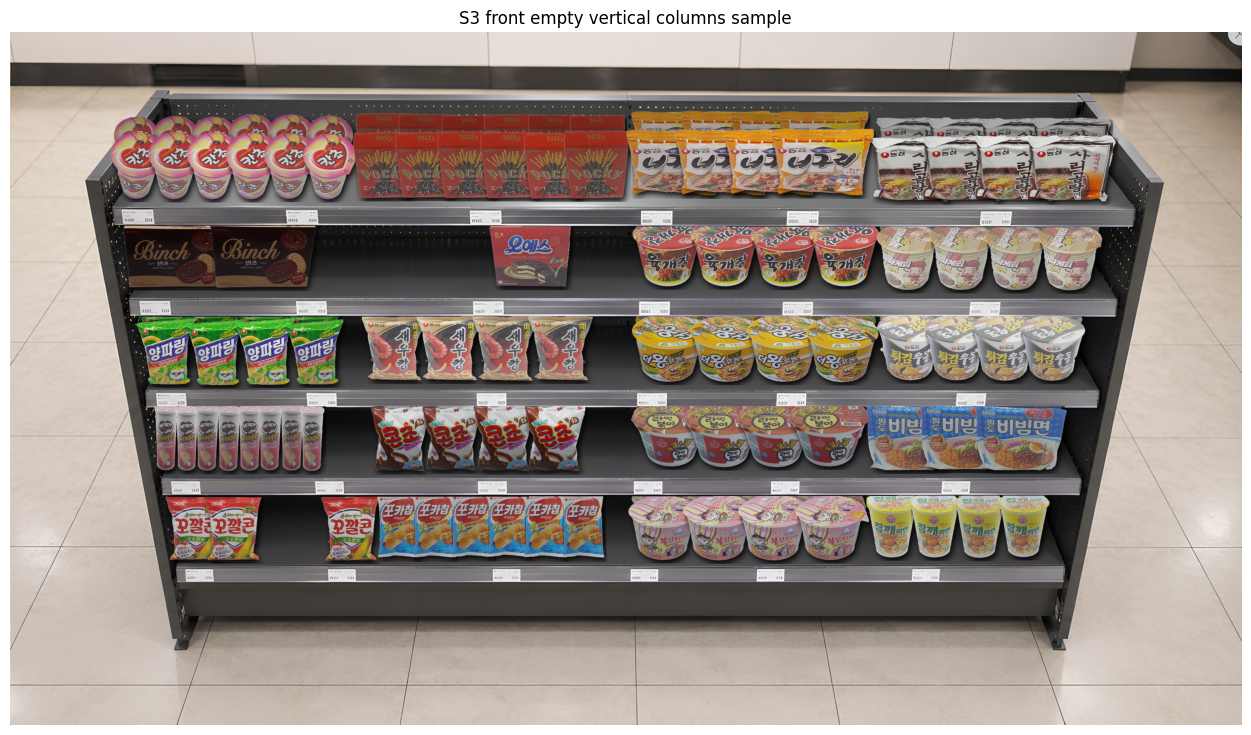

In [4]:
# ============================================================
# S3 정면 합성 + 이미지/라벨 저장
# 열 단위 공백 280장
# helper 함수 포함 통합 셀
# 랜덤 상품 배치 유지 버전: ctx를 루프 안에서 매번 생성
# ============================================================

from tqdm.auto import tqdm
import time
import random
import numpy as np
import re

SCENARIO_CODE = 'S3'
SCENARIO_NAME = '열 단위 공백'

NUM_IMAGES = 200
BASE_SEED = 330360


# ------------------------------------------------------------
# 0. 이 셀 단독 실행용 helper
# ------------------------------------------------------------

def get_next_start_index(image_dir, scenario_code):
    pattern = re.compile(rf'^synthetic_{scenario_code.lower()}_(\d{{3}})\.png$')
    max_num = 0

    for p in image_dir.glob(f'synthetic_{scenario_code.lower()}_*.png'):
        m = pattern.match(p.name)
        if m:
            max_num = max(max_num, int(m.group(1)))

    return max_num + 1


def sample_nonempty_subset(items, prob_range=(0.1, 0.4), keep_at_least_one_unselected=False):
    """
    개수를 직접 고정하지 않고, 매번 다른 확률로 subset을 랜덤 샘플링한다.
    """
    items = list(items)

    if len(items) == 0:
        return []

    p = random.uniform(*prob_range)
    selected = [x for x in items if random.random() < p]

    if not selected:
        selected = [random.choice(items)]

    if keep_at_least_one_unselected and len(items) > 1 and len(selected) == len(items):
        drop_one = random.choice(selected)
        selected = [x for x in selected if x != drop_one]

        if not selected:
            selected = [random.choice(items)]

    return selected


# ------------------------------------------------------------
# 1. SAHI 기준 최종 라벨 저장 경로
# ------------------------------------------------------------

IMAGE_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'images' / 'front' / SCENARIO_CODE.lower()
PRODUCT_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo' / 'front' / SCENARIO_CODE.lower()
SHELF_LIP_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo_seg' / 'front' / SCENARIO_CODE.lower()
JSON_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_json' / 'front' / SCENARIO_CODE.lower()

for d in [IMAGE_DIR, PRODUCT_YOLO_DIR, SHELF_LIP_YOLO_DIR, JSON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)

saved_paths = []
generation_logs = []
last_result = None
last_label_result = None

start_time = time.time()

pbar = tqdm(range(NUM_IMAGES), desc=f'{SCENARIO_CODE} 정면 생성 중', unit='img')


for image_idx in pbar:
    seed = BASE_SEED + image_idx

    random.seed(seed)
    np.random.seed(seed)

    if hasattr(synth, 'reset_random_seed'):
        synth.reset_random_seed(seed)

    # ------------------------------------------------------------
    # 2. 이미지마다 context 새로 생성
    # 중요:
    # create_synthetic_context 안에서 상품이 slot에 랜덤 배치되므로
    # 상품/위치가 매번 바뀌려면 반드시 루프 안에 있어야 함
    # ------------------------------------------------------------
    t_ctx0 = time.time()

    ctx_i = synth.create_synthetic_context(
        base_dir=BASE_DIR,
        background_name='선반이미지_정면.png',
        seed=seed,
    )

    t_ctx1 = time.time()

    # ------------------------------------------------------------
    # 3. S3 기본 정상 slot_plan 생성
    # ------------------------------------------------------------
    slot_plan = synth.make_normal_slot_plan(ctx_i)
    slot_ids = list(slot_plan.keys())

    # ------------------------------------------------------------
    # 4. S3 대상 슬롯 선택
    # 원본 S3 로직 유지:
    # 전체 슬롯 중 일부를 선택하고, 선택된 슬롯에서 열 단위로 앞/뒤를 같이 비움
    # ------------------------------------------------------------
    selected_slot_ids = sample_nonempty_subset(
        slot_ids,
        prob_range=(0.05, 0.30)
    )

    s3_logs = []
    per_slot_cols = {}

    # ------------------------------------------------------------
    # 5. 선택된 슬롯에 열 단위 공백 적용
    # ------------------------------------------------------------
    for slot_id in selected_slot_ids:
        target = slot_plan[slot_id]

        normal_front_qty = int(target.get('normal_front_qty', target.get('display_qty', 0)))
        normal_back_qty = int(target.get('normal_back_qty', target.get('back_display_qty', normal_front_qty)))

        if normal_front_qty <= 1:
            continue

        all_cols = list(range(normal_front_qty))

        # 슬롯마다 비울 열을 랜덤 선택
        # S3는 '열 단위 공백'이므로 전체 열이 다 비지 않도록 1개는 남김
        target_cols = sorted(
            sample_nonempty_subset(
                all_cols,
                prob_range=(0.20, 0.75),
                keep_at_least_one_unselected=True
            )
        )

        front_missing_indices = target_cols
        back_missing_indices = [
            col for col in target_cols
            if col < normal_back_qty
        ]

        front_display_qty = normal_front_qty - len(front_missing_indices)
        back_display_qty = normal_back_qty - len(back_missing_indices)

        missing_qty = len(front_missing_indices) + len(back_missing_indices)

        per_slot_cols[slot_id] = target_cols

        target.update({
            'scenario_code': SCENARIO_CODE,
            'sub_scenario_code': SCENARIO_CODE,
            'scenario_name': SCENARIO_NAME,
            'action': 'empty_vertical_columns',

            # S3는 리스트업 대상
            'list_up': True,
            'final_status': '보충 필요 / 발주 필요',
            'status_code': 'REPLENISH_REQUIRED',
            'status_label': '보충 필요',

            # 렌더링 호환용
            # display_qty/back_display_qty는 기준 수량 유지
            # missing_indices로 실제 비울 위치 지정
            'display_qty': normal_front_qty,
            'back_display_qty': normal_back_qty,

            # slot_state JSON용
            'required_front_qty': normal_front_qty,
            'required_back_qty': normal_back_qty,
            'front_display_qty': front_display_qty,
            'back_display_qty': back_display_qty,

            'front_missing_indices': front_missing_indices,
            'back_missing_indices': back_missing_indices,
            'back_visible_indices': None,

            'front_missing_qty': len(front_missing_indices),
            'back_missing_qty': len(back_missing_indices),
            'missing_qty': missing_qty,
            'missing_ratio': round(
                missing_qty / max(1, normal_front_qty + normal_back_qty),
                4
            ),

            'reduced_front_qty': front_display_qty,
            'target_column_index': target_cols,

            'extra_misplaced_items': [],
            'is_misplaced': False,
            'is_front_depleted': front_display_qty == 0,
            'is_slot_empty': False,
        })

        s3_logs.append({
            'slot_id': slot_id,
            'product_id': target.get('target_product_id'),
            'product_name': target.get('target_product_name'),
            'normal_front_qty': normal_front_qty,
            'normal_back_qty': normal_back_qty,
            'front_display_qty': front_display_qty,
            'back_display_qty': back_display_qty,
            'target_column_index': target_cols,
            'front_missing_indices': front_missing_indices,
            'back_missing_indices': back_missing_indices,
            'missing_qty': missing_qty,
            'status_code': 'REPLENISH_REQUIRED',
            'status_label': '보충 필요',
        })

    # ------------------------------------------------------------
    # 6. 선택되지 않은 슬롯은 정상 상태로 기록
    # ------------------------------------------------------------
    for slot_id, target in slot_plan.items():
        if target.get('action') == 'empty_vertical_columns':
            continue

        front_qty = int(target.get('normal_front_qty', target.get('display_qty', 0)))
        back_qty = int(target.get('normal_back_qty', target.get('back_display_qty', front_qty)))

        target.update({
            'scenario_code': SCENARIO_CODE,
            'sub_scenario_code': SCENARIO_CODE,
            'scenario_name': SCENARIO_NAME,
            'action': 'normal',
            'list_up': False,
            'final_status': '정상',

            'status_code': 'NORMAL',
            'status_label': '정상',

            'display_qty': front_qty,
            'back_display_qty': back_qty,

            'required_front_qty': front_qty,
            'required_back_qty': back_qty,
            'front_display_qty': front_qty,
            'back_display_qty': back_qty,

            'front_missing_indices': [],
            'back_missing_indices': [],
            'back_visible_indices': None,
            'extra_misplaced_items': [],

            'front_missing_qty': 0,
            'back_missing_qty': 0,
            'missing_qty': 0,
            'missing_ratio': 0.0,

            'reduced_front_qty': front_qty,
            'target_column_index': None,

            'is_misplaced': False,
            'is_front_depleted': False,
            'is_slot_empty': False,
        })

    # ------------------------------------------------------------
    # 7. 렌더링
    # ------------------------------------------------------------
    t_render0 = time.time()

    result, objects, slot_labels = synth.render_from_slot_plan(
        ctx=ctx_i,
        slot_plan=slot_plan,
        seed=seed
    )

    t_render1 = time.time()

    # ------------------------------------------------------------
    # 8. 저장 파일명
    # ------------------------------------------------------------
    file_no = start_idx + image_idx

    save_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.png'
    yolo_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.txt'
    json_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.json'

    save_path = IMAGE_DIR / save_name
    product_yolo_path = PRODUCT_YOLO_DIR / yolo_name
    shelf_lip_yolo_path = SHELF_LIP_YOLO_DIR / yolo_name
    json_path = JSON_DIR / json_name

    # ------------------------------------------------------------
    # 9. 이미지 + SAHI 기준 라벨 3종 저장
    # ------------------------------------------------------------
    t_label0 = time.time()

    label_result = labeler.save_sahi_labels(
        result=result,
        objects=objects,
        slot_labels=slot_labels,
        ctx=ctx_i,
        scenario_code=SCENARIO_CODE,
        scenario_name=SCENARIO_NAME,
        image_path=save_path,
        product_yolo_path=product_yolo_path,
        shelf_lip_yolo_path=shelf_lip_yolo_path,
        slot_json_path=json_path,
        seed=seed,
        view='front',
        settings_extra={
            'source_notebook': 'S3_정면시나리오_합성.ipynb',
            'label_structure': 'sahi_full_image',
            'scenario_rule': 'empty vertical columns',
            'ctx_reuse': False,
            'random_product_layout': True,
            's3_status_policy': 'empty_column_as_replenish_required',
        }
    )

    t_label1 = time.time()

    saved_paths.append(save_path)
    last_result = result
    last_label_result = label_result

    ctx_sec = round(t_ctx1 - t_ctx0, 2)
    render_sec = round(t_render1 - t_render0, 2)
    label_save_sec = round(t_label1 - t_label0, 2)
    total_sec = round(t_label1 - t_ctx0, 2)

    generation_logs.append({
        'file_name': save_name,
        'seed': seed,
        'scenario_code': SCENARIO_CODE,
        'scenario_name': SCENARIO_NAME,
        'n_targets': len(s3_logs),
        'targets': s3_logs,
        'per_slot_cols': per_slot_cols,
        'n_objects': len(objects),
        'n_slots': len(slot_labels),
        'ctx_sec': ctx_sec,
        'render_sec': render_sec,
        'label_save_sec': label_save_sec,
        'total_sec': total_sec,
        'image_path': str(save_path),
        'product_yolo_path': str(product_yolo_path),
        'shelf_lip_yolo_path': str(shelf_lip_yolo_path),
        'json_path': str(json_path),
        'label_result': label_result,
    })

    if (image_idx + 1) % 20 == 0 or (image_idx + 1) == NUM_IMAGES:
        elapsed = time.time() - start_time
        avg_sec = elapsed / (image_idx + 1)
        remain_sec = avg_sec * (NUM_IMAGES - (image_idx + 1))

        print(
            f'[{image_idx + 1}/{NUM_IMAGES}] 완료 | '
            f'최근 파일: {save_name} | '
            f'열 공백 대상: {len(s3_logs)}개 | '
            f'ctx: {ctx_sec}초 | '
            f'render: {render_sec}초 | '
            f'label: {label_save_sec}초 | '
            f'평균: {avg_sec:.2f}초/장 | '
            f'예상 남은 시간: {remain_sec/60:.1f}분'
        )

total_time = time.time() - start_time

print('\nS3 정면 생성 완료')
print(f'총 생성 수: {len(saved_paths)}장')
print(f'총 소요 시간: {total_time/60:.2f}분')
print(f'평균 시간: {total_time / len(saved_paths):.2f}초/장')

print('이미지 저장 폴더:', IMAGE_DIR)
print('상품 YOLO 저장 폴더:', PRODUCT_YOLO_DIR)
print('선반 앞턱 YOLO-seg 저장 폴더:', SHELF_LIP_YOLO_DIR)
print('slot_state JSON 저장 폴더:', JSON_DIR)

print('\n처음 5개 파일:')
for p in saved_paths[:5]:
    print('-', p.name)

print('\n마지막 이미지:', saved_paths[-1])
synth.show_image(last_result, title=f'{SCENARIO_CODE} front empty vertical columns sample')

In [ ]:
ctx = synth.create_synthetic_context(
    base_dir=BASE_DIR,
    background_name='선반이미지_정면.png',
    seed=42,
)

print('배경:', ctx['paths']['background_path'])
print('과자 상품 폴더 수:', len(ctx['snack_product_dirs']))
print('면류 상품 폴더 수:', len(ctx['noodle_product_dirs']))
print('전체 slot 수:', len(ctx['all_slots']))
print('class 수:', len(ctx['class_map']))


배경: /content/drive/MyDrive/먼작귀/창고 이미지/선반이미지_정면.png
과자 상품 폴더 수: 10
면류 상품 폴더 수: 13
전체 slot 수: 20
class 수: 23


In [ ]:
def get_next_start_index(image_dir, scenario_code):
    pattern = re.compile(rf'^synthetic_{scenario_code.lower()}_(\d{{3}})\.png$')
    max_num = 0
    for p in image_dir.glob(f'synthetic_{scenario_code.lower()}_*.png'):
        m = pattern.match(p.name)
        if m:
            max_num = max(max_num, int(m.group(1)))
    return max_num + 1


def sample_nonempty_subset(items, prob_range=(0.1, 0.4), keep_at_least_one_unselected=False):
    """개수를 직접 고정하지 않고, 매번 다른 확률로 subset을 랜덤 샘플링한다."""
    if len(items) == 0:
        return []

    p = random.uniform(*prob_range)
    selected = [x for x in items if random.random() < p]

    if not selected:
        selected = [random.choice(items)]

    if keep_at_least_one_unselected and len(items) > 1 and len(selected) == len(items):
        drop_one = random.choice(selected)
        selected = [x for x in selected if x != drop_one]
        if not selected:
            selected = [random.choice(items)]

    return selected


In [ ]:
SCENARIO_CODE = 'S3'
SCENARIO_NAME = '열 단위 공백'
NUM_IMAGES = 100
BASE_SEED = 330360

IMAGE_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'images' / 'front' / SCENARIO_CODE.lower()
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)
saved_paths = []
generation_logs = []
last_result = None

for image_idx in range(NUM_IMAGES):
    seed = BASE_SEED + image_idx
    random.seed(seed)

    # 핵심 수정:
    # 이미지마다 ctx를 새로 만들어서
    # 과자 슬롯 안에서는 과자 상품끼리 랜덤,
    # 면류 슬롯 안에서는 면류 상품끼리 랜덤 배치되도록 함
    ctx = synth.create_synthetic_context(
        base_dir=BASE_DIR,
        background_name='선반이미지_정면.png',
        seed=seed,
    )

    slot_plan = synth.make_normal_slot_plan(ctx)
    slot_ids = list(slot_plan.keys())

    selected_slot_ids = sample_nonempty_subset(
        slot_ids,
        prob_range=(0.05, 0.30)
    )

    per_slot_cols = {}

    for slot_id in selected_slot_ids:
        target = slot_plan[slot_id]
        normal_qty = int(target['normal_front_qty'])
        all_cols = list(range(normal_qty))

        # 슬롯마다 비울 열을 랜덤 선택
        target_cols = sorted(
            sample_nonempty_subset(
                all_cols,
                prob_range=(0.2, 0.75)
            )
        )

        per_slot_cols[slot_id] = target_cols

        target.update({
            'scenario_code': 'S3',
            'action': 'empty_vertical_columns',
            'list_up': True,
            'final_status': '보충 필요 / 발주 필요',
            'front_missing_indices': target_cols,
            'back_missing_indices': target_cols,
            'missing_qty': len(target_cols) * 2,
            'target_column_index': target_cols,
        })

    result, objects, slot_labels = synth.render_from_slot_plan(
        ctx=ctx,
        slot_plan=slot_plan,
        seed=seed
    )

    save_name = f'synthetic_{SCENARIO_CODE.lower()}_{start_idx + image_idx:03d}.png'
    save_path = IMAGE_DIR / save_name

    result.convert('RGB').save(save_path)

    saved_paths.append(save_path)
    last_result = result

    generation_logs.append({
        'file_name': save_name,
        'seed': seed,
        'n_targets': len(selected_slot_ids),
        'per_slot_cols': per_slot_cols,
    })

print('예시 로그 3개:')
for log in generation_logs[:3]:
    print(log)

예시 로그 3개:
{'file_name': 'synthetic_s3_002.png', 'seed': 330360, 'n_targets': 5, 'per_slot_cols': {'noodle-01': [2], 'noodle-02': [2], 'noodle-04': [0], 'noodle-07': [2], 'noodle-09': [1]}}
{'file_name': 'synthetic_s3_003.png', 'seed': 330361, 'n_targets': 4, 'per_slot_cols': {'snack-01': [0, 2, 3, 4, 5], 'snack-02': [0, 2], 'noodle-04': [1], 'noodle-07': [0, 3]}}
{'file_name': 'synthetic_s3_004.png', 'seed': 330362, 'n_targets': 6, 'per_slot_cols': {'snack-04': [2, 3], 'snack-05': [0, 2, 3], 'snack-08': [0, 2, 5], 'noodle-02': [0], 'noodle-04': [0], 'noodle-09': [0, 3]}}


생성 완료: 100장
저장 폴더: /content/drive/MyDrive/먼작귀/dataset/synthetic/images/s3
처음 5개 파일:
- synthetic_s3_002.png
- synthetic_s3_003.png
- synthetic_s3_004.png
- synthetic_s3_005.png
- synthetic_s3_006.png
마지막 이미지 미리보기: synthetic_s3_101.png


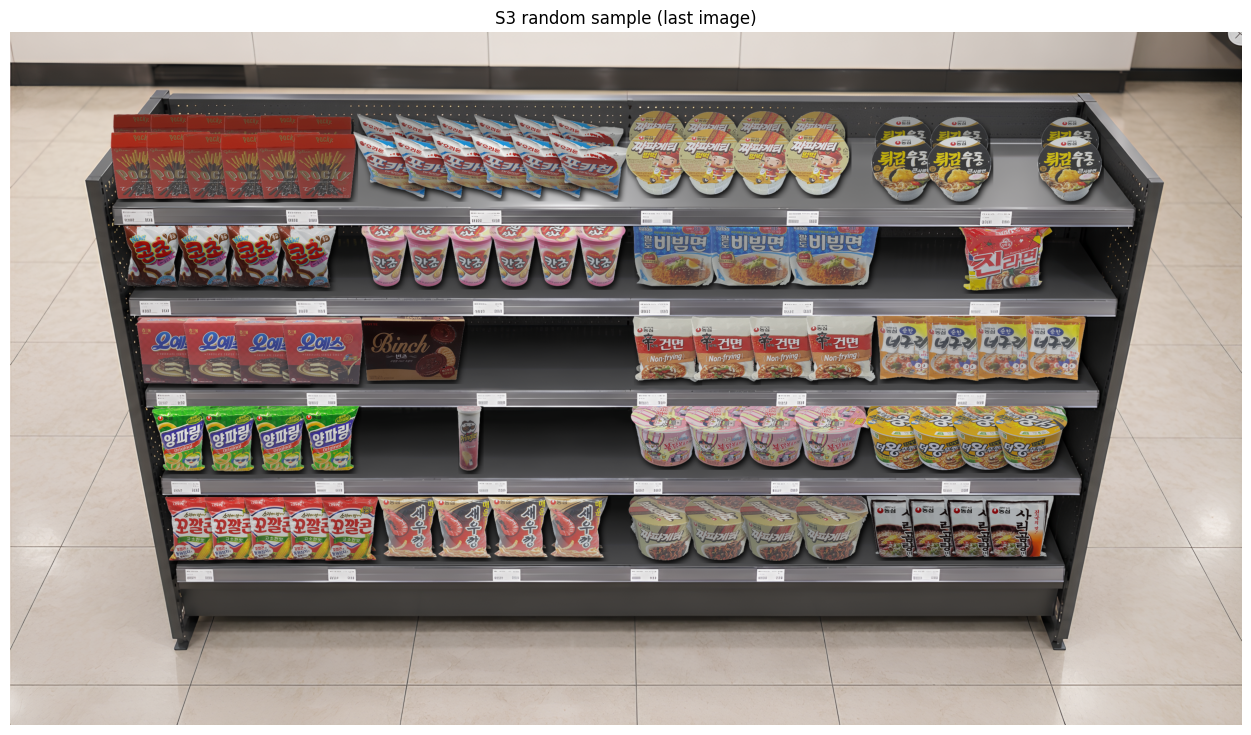

In [ ]:
print(f'생성 완료: {len(saved_paths)}장')
print('저장 폴더:', IMAGE_DIR)
print('처음 5개 파일:')
for p in saved_paths[:5]:
    print('-', p.name)

print('마지막 이미지 미리보기:', saved_paths[-1].name)
synth.show_image(last_result, title=f'{SCENARIO_CODE} random sample (last image)')
